# Segmentation

Demonstrates object segmentation using `MobileSAMSegmentation` with two strategies:
- **object** — YOLOv8 bounding boxes → SAM masks (recommended for distinct objects)
- **auto** — SAM automatic mask generator (denser coverage)

Closes with **§3 Masks → Features**: how to aggregate per-segment feature vectors using `aggregate_masked_features`, bridging segmentation and feature extraction.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch
from PIL import Image

%matplotlib inline

from collab_splats.semantics import MobileSAMSegmentation, MaskCLIPExtractor, aggregate_masked_features
from collab_splats.utils.visualization import overlay_masks, pca_to_rgb

/opt/venv/reconstruction/lib/python3.11/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/opt/venv/reconstruction/lib/python3.11/site-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/opt/venv/reconstruction/lib/python3.11/site-packages/mobile_sam/modeling/tiny_vit_sam.py:656: UserWarning: Overwriting tiny_vit_5m_224 in registry with mobile_sam.modeling.tiny_vit_sam.tiny_vit_5m_224. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
  return register_model(fn_wrapper)
/opt/venv/reconstruction/lib/python3.11/site-packages/mobile_sam/modeling/ti

Device: cuda  |  Frame: 00000.jpg  shape=(1920, 1080, 3)


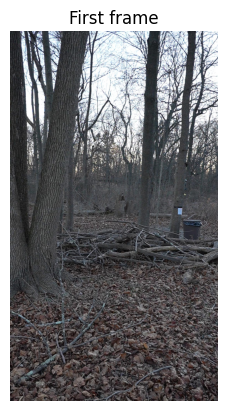

In [3]:
%run ../tutorial_config.py

# ── Configuration ─────────────────────────────────────────────────────────────


assert FRAMES.exists() and any(
    FRAMES.glob("*.jpg")
), f"No keyframes in {FRAMES}. Run 01_preprocessing/keyframe_extraction first."

device = "cuda" if torch.cuda.is_available() else "cpu"
frame_path = sorted(FRAMES.glob("*.jpg"))[0]
frame = np.array(Image.open(frame_path))
print(f"Device: {device}  |  Frame: {frame_path.name}  shape={frame.shape}")

plt.imshow(frame)
plt.axis("off")
plt.title("First frame")
plt.show()

## §1 — Object Strategy

Uses YOLOv8 to detect bounding boxes, then SAM to produce per-object masks.
Best for scenes with distinct foreground objects — each box gets one mask.

In [4]:
# Load model with object strategy and run segmentation
seg_object = MobileSAMSegmentation(strategy="object", device=device)
print("Segmentation model loaded.")

result_object = seg_object.segment(frame)
if result_object is not None:
    masks_object, metadata_object = result_object  # masks: (N, H, W) float32
    print(f"{len(metadata_object)} objects detected")
else:
    print("No objects detected.")
    masks_object = None

Using cache found in /workspace/models/hub/RogerQi_MobileSAMV2_main
/workspace/models/hub/RogerQi_MobileSAMV2_main/mobilesamv2/tinyvit/tiny_vit.py:656: UserWarning: Overwriting tiny_vit_5m_224 in registry with mobilesamv2.tinyvit.tiny_vit.tiny_vit_5m_224. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
  return register_model(fn_wrapper)
/workspace/models/hub/RogerQi_MobileSAMV2_main/mobilesamv2/tinyvit/tiny_vit.py:656: UserWarning: Overwriting tiny_vit_11m_224 in registry with mobilesamv2.tinyvit.tiny_vit.tiny_vit_11m_224. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
  return register_model(fn_wrapper)
/workspace/models/hub/RogerQi_MobileSAMV2_main/mobilesamv2/tinyvit/tiny_vit.py:656: UserWarning: Overwriting tiny_vit_21m_224 in registry with mobilesamv2.tinyvit.tiny_vit.tiny_vit_21m_224. This is because the name being registered conflicts with an existi

/workspace/models/hub/RogerQi_MobileSAMV2_main/mobilesamv2/efficientvit/models/nn/ops.py:395: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @autocast(enabled=False)


/workspace/models/hub/RogerQi_MobileSAMV2_main/mobilesamv2/build_sam.py:207: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(f)


/workspace/models/hub/RogerQi_MobileSAMV2_main/mobilesamv2/build_sam.py:138: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoints = torch.load(checkpoint)


checkpoint_load_scucess


Segmentation model loaded.


0: 1024x576 62 objects, 73.9ms


Speed: 7.1ms preprocess, 73.9ms inference, 61.2ms postprocess per image at shape (1, 3, 1024, 1024)


62 objects detected


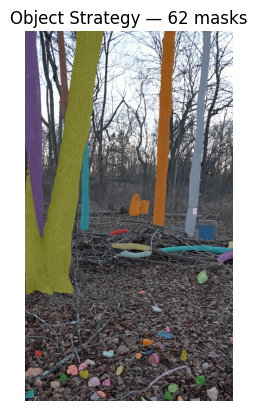

In [5]:
# Visualize object masks overlaid on the original frame
if masks_object is not None:
    plt.imshow(overlay_masks(frame, masks_object))
    plt.axis("off")
    plt.title(f"Object Strategy — {len(metadata_object)} masks")
    plt.show()

## §2 — Auto Strategy

SAM automatic mask generator without object detection priors.
Produces denser, smaller segments — useful for fine-grained coverage when object boundaries are not well-defined.

In [6]:
# Load model with auto strategy and run segmentation
seg_auto = MobileSAMSegmentation(strategy="auto", device=device)
print("Auto segmentation model loaded.")

result_auto = seg_auto.segment(frame)
if result_auto is not None:
    masks_auto, metadata_auto = result_auto
    print(f"{len(metadata_auto)} segments detected")
else:
    print("No segments detected.")
    masks_auto = None

Using cache found in /workspace/models/hub/RogerQi_MobileSAMV2_main


/workspace/models/hub/RogerQi_MobileSAMV2_main/mobilesamv2/build_sam.py:207: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(f)


/workspace/models/hub/RogerQi_MobileSAMV2_main/mobilesamv2/build_sam.py:138: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoints = torch.load(checkpoint)


checkpoint_load_scucess
Auto segmentation model loaded.


42 segments detected


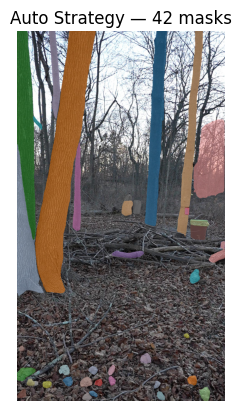

In [7]:
# Visualize auto masks overlaid on the original frame
if masks_auto is not None:
    plt.imshow(overlay_masks(frame, masks_auto))
    plt.axis("off")
    plt.title(f"Auto Strategy — {len(metadata_auto)} masks")
    plt.show()

## §3 — Masks → Features

`aggregate_masked_features` pools feature vectors per mask region, bridging segmentation and feature extraction.
Instead of per-pixel features you get one feature vector per detected object.

`MaskCLIPExtractor` is used here because it returns spatial `(C, pH, pW)` features — the required input format for `aggregate_masked_features`.

In [8]:
# MaskCLIPExtractor returns spatial (C, pH, pW) — required by aggregate_masked_features.
# Talk2DinoExtractor returns flat (N_patches, D) and would need an explicit reshape first.
extractor = MaskCLIPExtractor()
print("MaskCLIP loaded.")

MaskCLIP loaded.


In [9]:
# Extract spatial features then aggregate per object mask
agg = None
if masks_object is not None:
    pil_frame = Image.fromarray(frame)
    features = extractor.forward([pil_frame])  # list of (C, pH, pW)

    H, W = frame.shape[:2]
    masks_for_agg = masks_object  # (N, H, W) float32

    agg = aggregate_masked_features(
        features[0],
        masks_for_agg,
        resolution=(H // 4, W // 4),
        final_resolution=(H, W),
    )
    print("Aggregated features shape:", agg.shape)  # (C, H, W)
else:
    print("No object masks available — run the Object Strategy section first.")

Aggregated features shape: torch.Size([768, 1920, 1080])


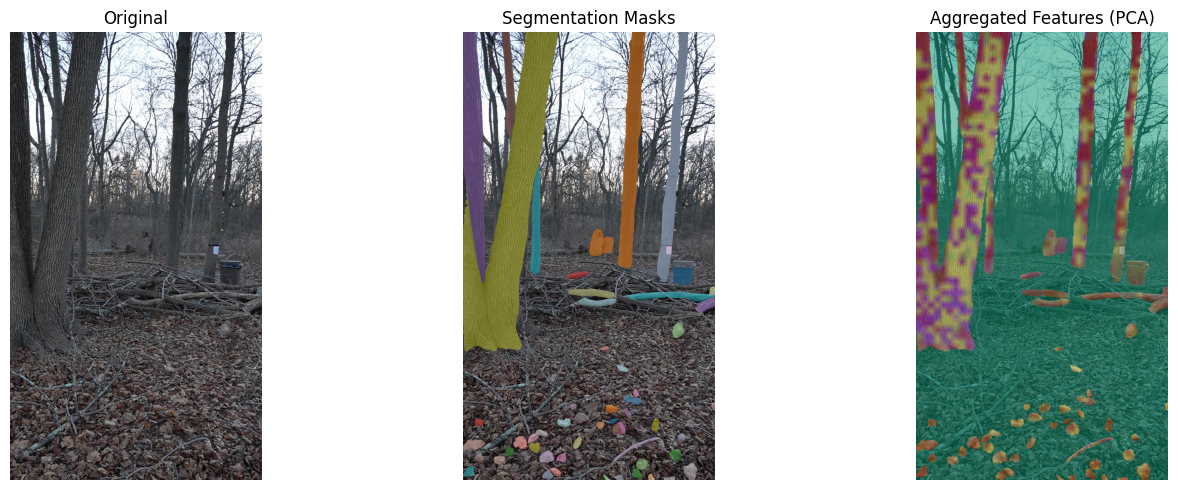

In [10]:
# Side-by-side: original | masks | PCA projection of aggregated features
if agg is not None:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(frame)
    axes[0].set_title("Original")
    axes[1].imshow(overlay_masks(frame, masks_for_agg))
    axes[1].set_title("Segmentation Masks")
    axes[2].imshow(pca_to_rgb(agg, frame))
    axes[2].set_title("Aggregated Features (PCA)")
    for ax in axes:
        ax.axis("off")
    plt.tight_layout()
    plt.show()